In [1]:
# Libraries and configurations
import sys
from pathlib import Path
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import transforms
from torchinfo import summary

# Visualization and analysis
import seaborn as sns
import PIL
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score

# Adds the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import (
    get_dataset_paths
)

from src.dataset import DataModuleParasite

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

### Configurações gerais

In [2]:
# Functions for training and evaluation

class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    
    train_loss_avg = AverageMeter()
    train_acc_avg = AverageMeter()

    for input, label in tqdm(train_loader, desc="Training", leave=False):
        input, label = input.to(device), label.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(input)
        loss = criterion(outputs, label)

        # Backward
        loss.backward()
        optimizer.step()
        
        # Predictions
        _, preds = torch.max(outputs, 1)
        
        # Metrics for batch
        batch_acc = (preds == label).sum().item() / label.size(0)

        train_loss_avg.update(loss.item(), label.size(0))
        train_acc_avg.update(batch_acc, label.size(0))

    return train_loss_avg.avg, train_acc_avg.avg

def evaluate(model, val_loader, criterion, device):
    model.eval()
    
    val_loss_avg = AverageMeter()
    val_acc_avg = AverageMeter()
    
    with torch.no_grad():
        for input, label in tqdm(val_loader, desc="Validation", leave=False):
            input, label = input.to(device), label.to(device)

            # Forward
            outputs = model(input)
            loss = criterion(outputs, label)

            # Predictions
            _, preds = torch.max(outputs, 1)

            # Metrics for batch
            batch_acc = (preds == label).sum().item() / label.size(0)

            val_loss_avg.update(loss.item(), label.size(0))
            val_acc_avg.update(batch_acc, label.size(0))

    return val_loss_avg.avg, val_acc_avg.avg

### Eggs 

In [3]:
# Configuration for Larvae Dataset
CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_egg = {}

transforms_egg = transforms.Compose([
    transforms.Resize((CONFIG_EGG['image_size'], CONFIG_EGG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_EGG['split']:
    dataloaders_egg[split] = {}
    for perc in CONFIG_EGG['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_EGG['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_EGG['batch_size'],
            num_workers=CONFIG_EGG['num_workers'],
            transform=transforms_egg
        )
        data_module.setup()
        dataloaders_egg[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }
    
# Model
vgg16_model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_model_pretrained.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_EGG['num_classes'])
vgg16_model_pretrained = vgg16_model_pretrained.to(CONFIG_EGG['device'])

total_params = sum(p.numel() for p in vgg16_model_pretrained.parameters())
trainable_params = sum(p.numel() for p in vgg16_model_pretrained.parameters() if p.requires_grad)

# print(f"Total parameters: {total_params}")
# print(f"Trainable parameters: {trainable_params}")
# print(summary(vgg16_model_pretrained, input_size=(1, 3, 224, 224)))

# Loss , Optimizer and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model_pretrained.parameters(), lr=CONFIG_EGG['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
# Training loop
historic_perc = {} 

for perc in CONFIG_EGG['percentage']:
    patience = 20
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    best_val_acc = 0.0
    historic_perc[perc] = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in tqdm(range(CONFIG_EGG['num_epochs']), desc=f"Percentage {perc}%", leave=False):
        
        train_loss, train_acc = train(vgg16_model_pretrained, dataloaders_perc[perc]['train'], criterion, optimizer, CONFIG_EGG['device'])

        val_loss, val_acc = evaluate(vgg16_model_pretrained, dataloaders_perc[perc]['val'], criterion, CONFIG_EGG['device'])

        historic_perc[perc]['train_loss'].append(train_loss)
        historic_perc[perc]['train_acc'].append(train_acc)
        historic_perc[perc]['val_loss'].append(val_loss)
        historic_perc[perc]['val_acc'].append(val_acc)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(vgg16_model_pretrained.state_dict(), f'vgg16_egg_best_acc_perc_{perc}_split{CONFIG_EGG["split"]}.pth')

        scheduler.step()

In [ ]:
# Loss and Accuracy plots
for perc in CONFIG_EGG['percentage']:
    epochs = range(1, len(historic_perc[perc]['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historic_perc[perc]['train_loss'], label='Train Loss')
    plt.plot(epochs, historic_perc[perc]['val_loss'], label='Validation Loss')
    plt.title(f'Loss per Epoch (Percentage {perc}%)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historic_perc[perc]['train_acc'], label='Train Accuracy')
    plt.plot(epochs, historic_perc[perc]['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy per Epoch (Percentage {perc}%)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
   

In [ ]:
from sklearn.metrics import cohen_kappa_score

# Avaliaton on test set
for perc in CONFIG_EGG['percentage']:
    # Load the best model
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_EGG['num_classes'])
    model.load_state_dict(torch.load(f'vgg16_egg_best_acc_perc_{perc}_split{CONFIG_EGG["split"]}.pth'))
    model = model.to(CONFIG_EGG['device'])
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input, label in tqdm(dataloaders_perc[perc]['test'], desc=f"Testing Percentage {perc}%", leave=False):
            input, label = input.to(CONFIG_EGG['device']), label.to(CONFIG_EGG['device'])

            outputs = model(input)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Confusion Matrix (normalizada por linha - recall por classe)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
    # evita NaNs quando alguma linha tem soma 0
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=list(range(CONFIG_EGG['num_classes'])),
                yticklabels=list(range(CONFIG_EGG['num_classes'])))
    plt.title(f'Confusion Matrix Normalizada (Percentage {perc}%)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Kappa
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'Kappa (Cohen) (Percentage {perc}%): {kappa:.4f}')

    # Classification Report
    report = classification_report(all_labels, all_preds)
    print(f'Classification Report (Percentage {perc}%):\n{report}')

### Cistos

In [12]:
# Configuration for Larvae Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_cisto = {}

transforms_cisto = transforms.Compose([
    transforms.Resize((CONFIG_CISTO['image_size'], CONFIG_CISTO['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_CISTO['split']:
    dataloaders_cisto[split] = {}
    for perc in CONFIG_CISTO['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_CISTO['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_CISTO['batch_size'],
            num_workers=CONFIG_CISTO['num_workers'],
            transform=transforms_cisto
        )
        data_module.setup()
        dataloaders_cisto[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }
    
# Model
vgg16_model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_model_pretrained.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_CISTO['num_classes'])
vgg16_model_pretrained = vgg16_model_pretrained.to(CONFIG_CISTO['device'])

total_params = sum(p.numel() for p in vgg16_model_pretrained.parameters())
trainable_params = sum(p.numel() for p in vgg16_model_pretrained.parameters() if p.requires_grad)

# print(f"Total parameters: {total_params}")
# print(f"Trainable parameters: {trainable_params}")
# print(summary(vgg16_model_pretrained, input_size=(1, 3, 224, 224)))

# Loss , Optimizer and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model_pretrained.parameters(), lr=CONFIG_CISTO['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

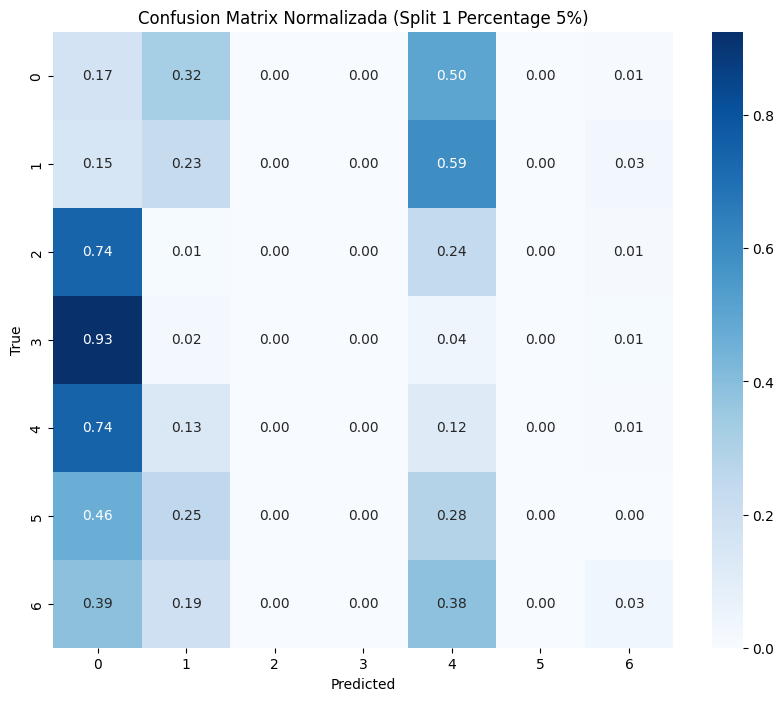

Kappa (Cohen) (Split 1 Percentage 5%): -0.0542
Classification Report (Split 1 Percentage 5%):
              precision    recall  f1-score   support

           0       0.03      0.17      0.05       360
           1       0.01      0.23      0.02        39
           2       0.00      0.00      0.00       362
           3       0.00      0.00      0.00       321
           4       0.06      0.12      0.08       751
           5       0.00      0.00      0.00        95
           6       0.86      0.03      0.06      2858

    accuracy                           0.05      4786
   macro avg       0.14      0.08      0.03      4786
weighted avg       0.53      0.05      0.05      4786

Class Accuracy (Split 1 Percentage 5%):


,correct,total,accuracy,accuracy_pct
class_0,62,360,0.172222,17.22
class_1,9,39,0.230769,23.08
class_2,0,362,0.000000,0.00
class_3,0,321,0.000000,0.00
class_4,87,751,0.115846,11.58
class_5,0,95,0.000000,0.00
class_6,96,2858,0.033590,3.36


Overall accuracy: 0.0531    Kappa: -0.0542


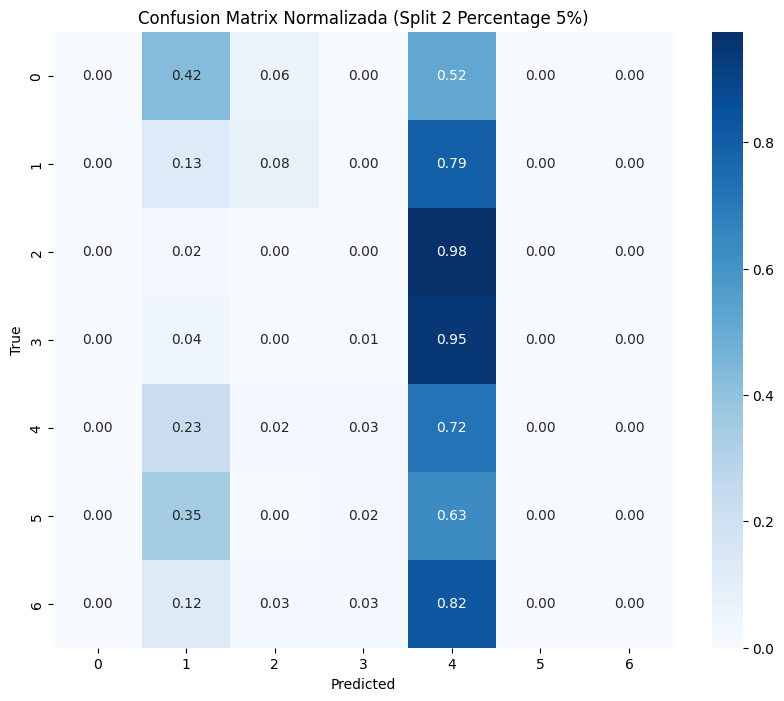

Kappa (Cohen) (Split 2 Percentage 5%): -0.0171
Classification Report (Split 2 Percentage 5%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.01      0.13      0.01        39
           2       0.01      0.00      0.00       362
           3       0.03      0.01      0.01       321
           4       0.14      0.72      0.24       751
           5       0.00      0.00      0.00        95
           6       1.00      0.00      0.00      2858

    accuracy                           0.12      4786
   macro avg       0.17      0.12      0.04      4786
weighted avg       0.62      0.12      0.04      4786

Class Accuracy (Split 2 Percentage 5%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,5,39,0.128205,12.82
class_2,1,362,0.002762,0.28
class_3,3,321,0.009346,0.93
class_4,542,751,0.721704,72.17
class_5,0,95,0.000000,0.00
class_6,1,2858,0.000350,0.03


Overall accuracy: 0.1153    Kappa: -0.0171


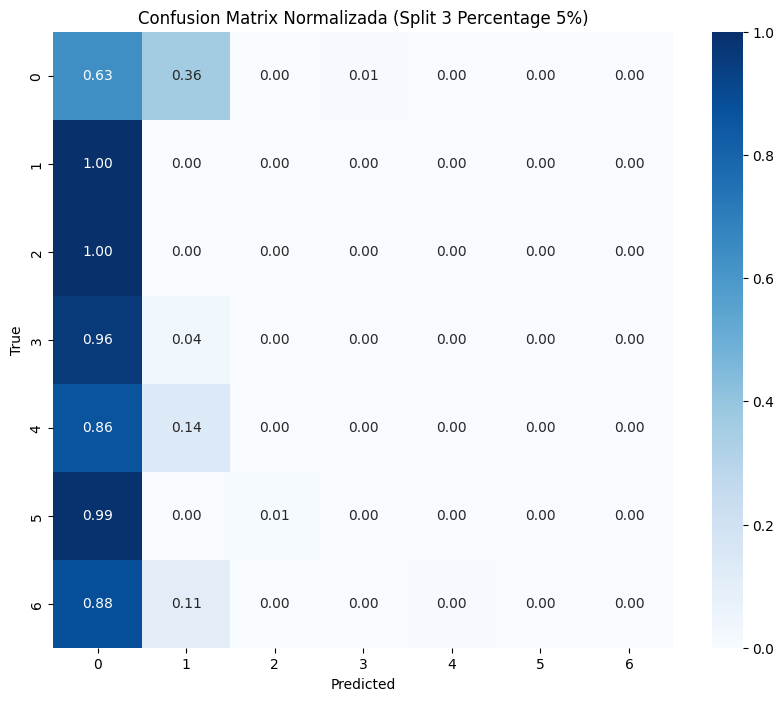

Kappa (Cohen) (Split 3 Percentage 5%): -0.0212
Classification Report (Split 3 Percentage 5%):
              precision    recall  f1-score   support

           0       0.05      0.63      0.10       360
           1       0.00      0.00      0.00        39
           2       0.00      0.00      0.00       362
           3       0.00      0.00      0.00       321
           4       0.00      0.00      0.00       751
           5       0.00      0.00      0.00        95
           6       1.00      0.00      0.00      2858

    accuracy                           0.05      4786
   macro avg       0.15      0.09      0.01      4786
weighted avg       0.60      0.05      0.01      4786

Class Accuracy (Split 3 Percentage 5%):


,correct,total,accuracy,accuracy_pct
class_0,228,360,0.633333,63.33
class_1,0,39,0.000000,0.00
class_2,0,362,0.000000,0.00
class_3,0,321,0.000000,0.00
class_4,0,751,0.000000,0.00
class_5,0,95,0.000000,0.00
class_6,2,2858,0.000700,0.07


Overall accuracy: 0.0481    Kappa: -0.0212


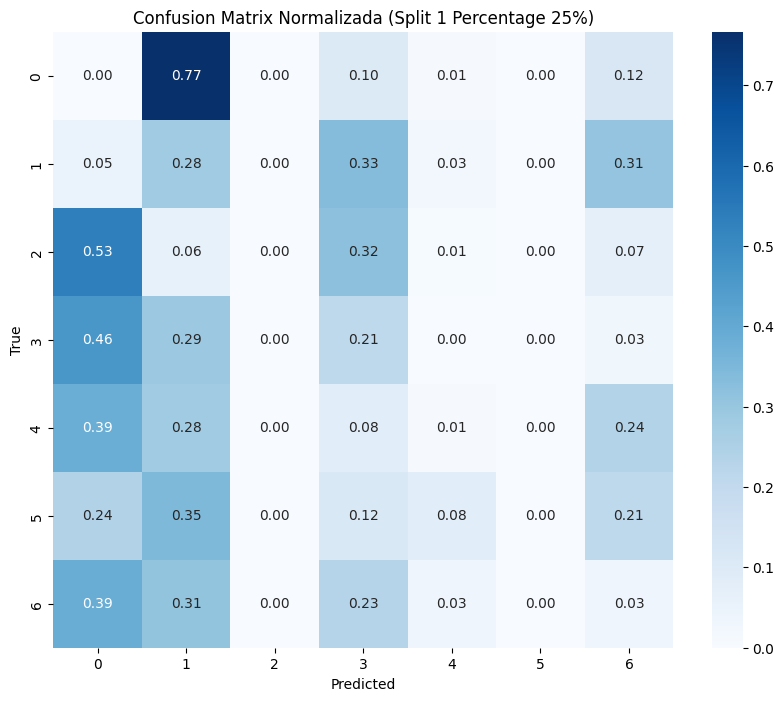

Kappa (Cohen) (Split 1 Percentage 25%): -0.0642
Classification Report (Split 1 Percentage 25%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.01      0.28      0.01        39
           2       0.00      0.00      0.00       362
           3       0.07      0.21      0.10       321
           4       0.06      0.01      0.02       751
           5       0.00      0.00      0.00        95
           6       0.25      0.03      0.06      2858

    accuracy                           0.04      4786
   macro avg       0.06      0.08      0.03      4786
weighted avg       0.16      0.04      0.05      4786

Class Accuracy (Split 1 Percentage 25%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,11,39,0.282051,28.21
class_2,0,362,0.000000,0.00
class_3,68,321,0.211838,21.18
class_4,8,751,0.010652,1.07
class_5,0,95,0.000000,0.00
class_6,97,2858,0.033940,3.39


Overall accuracy: 0.0384    Kappa: -0.0642


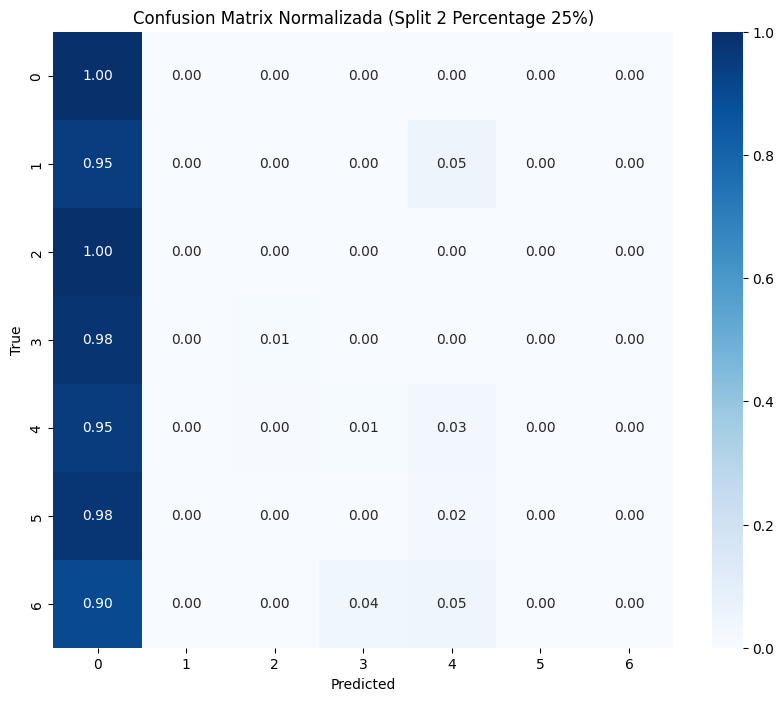

Kappa (Cohen) (Split 2 Percentage 25%): 0.0032
Classification Report (Split 2 Percentage 25%):
              precision    recall  f1-score   support

           0       0.08      1.00      0.15       360
           1       0.00      0.00      0.00        39
           2       0.00      0.00      0.00       362
           3       0.01      0.00      0.00       321
           4       0.15      0.03      0.06       751
           5       0.00      0.00      0.00        95
           6       0.00      0.00      0.00      2858

    accuracy                           0.08      4786
   macro avg       0.03      0.15      0.03      4786
weighted avg       0.03      0.08      0.02      4786

Class Accuracy (Split 2 Percentage 25%):


,correct,total,accuracy,accuracy_pct
class_0,359,360,0.997222,99.72
class_1,0,39,0.000000,0.00
class_2,0,362,0.000000,0.00
class_3,1,321,0.003115,0.31
class_4,26,751,0.034621,3.46
class_5,0,95,0.000000,0.00
class_6,0,2858,0.000000,0.00


Overall accuracy: 0.0807    Kappa: 0.0032


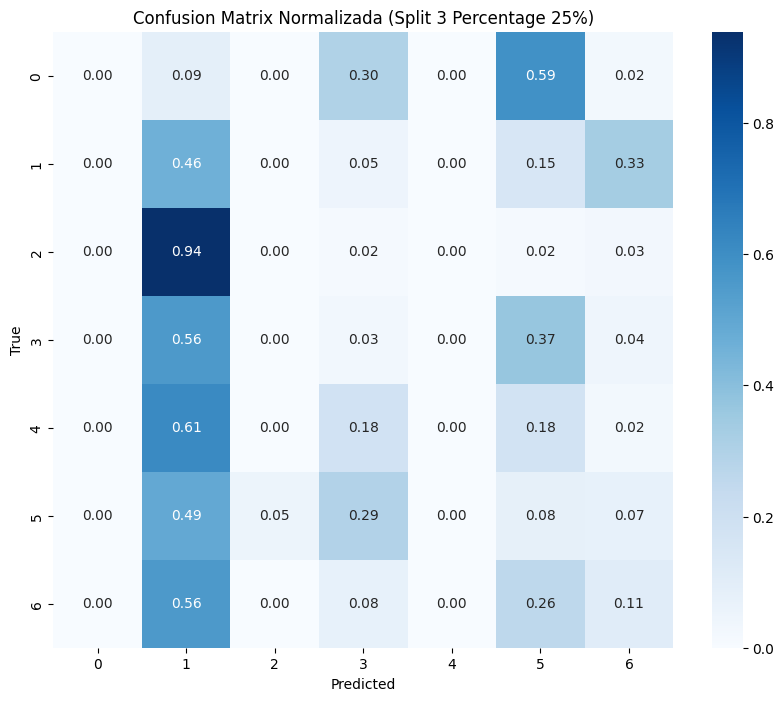

Kappa (Cohen) (Split 3 Percentage 25%): 0.0083
Classification Report (Split 3 Percentage 25%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.01      0.46      0.01        39
           2       0.00      0.00      0.00       362
           3       0.02      0.03      0.02       321
           4       0.00      0.00      0.00       751
           5       0.01      0.08      0.01        95
           6       0.82      0.11      0.19      2858

    accuracy                           0.07      4786
   macro avg       0.12      0.10      0.03      4786
weighted avg       0.49      0.07      0.12      4786

Class Accuracy (Split 3 Percentage 25%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,18,39,0.461538,46.15
class_2,0,362,0.000000,0.00
class_3,10,321,0.031153,3.12
class_4,0,751,0.000000,0.00
class_5,8,95,0.084211,8.42
class_6,307,2858,0.107418,10.74


Overall accuracy: 0.0717    Kappa: 0.0083


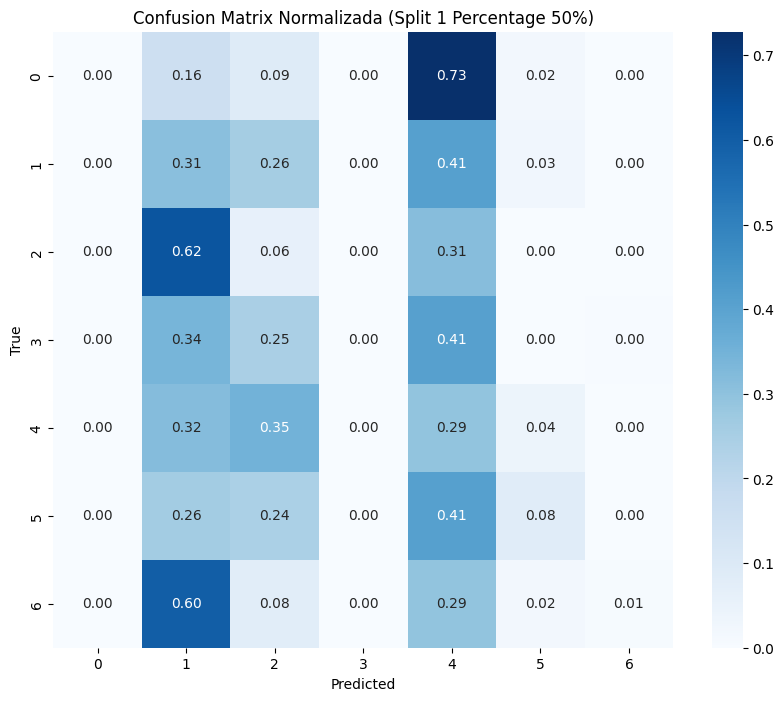

Kappa (Cohen) (Split 1 Percentage 50%): -0.0125
Classification Report (Split 1 Percentage 50%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.01      0.31      0.01        39
           2       0.03      0.06      0.04       362
           3       0.00      0.00      0.00       321
           4       0.14      0.29      0.19       751
           5       0.08      0.08      0.08        95
           6       0.95      0.01      0.01      2858

    accuracy                           0.06      4786
   macro avg       0.17      0.11      0.05      4786
weighted avg       0.60      0.06      0.04      4786

Class Accuracy (Split 1 Percentage 50%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,12,39,0.307692,30.77
class_2,22,362,0.060773,6.08
class_3,0,321,0.000000,0.00
class_4,221,751,0.294274,29.43
class_5,8,95,0.084211,8.42
class_6,21,2858,0.007348,0.73


Overall accuracy: 0.0593    Kappa: -0.0125


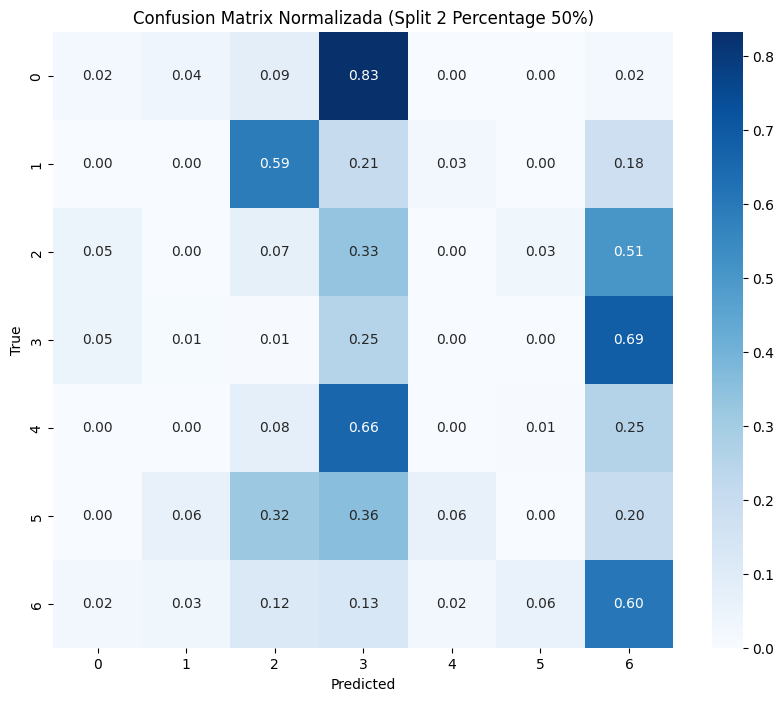

Kappa (Cohen) (Split 2 Percentage 50%): 0.0863
Classification Report (Split 2 Percentage 50%):
              precision    recall  f1-score   support

           0       0.06      0.02      0.03       360
           1       0.00      0.00      0.00        39
           2       0.05      0.07      0.06       362
           3       0.06      0.25      0.09       321
           4       0.00      0.00      0.00       751
           5       0.00      0.00      0.00        95
           6       0.73      0.60      0.66      2858

    accuracy                           0.39      4786
   macro avg       0.13      0.14      0.12      4786
weighted avg       0.45      0.39      0.41      4786

Class Accuracy (Split 2 Percentage 50%):


,correct,total,accuracy,accuracy_pct
class_0,7,360,0.019444,1.94
class_1,0,39,0.000000,0.00
class_2,27,362,0.074586,7.46
class_3,81,321,0.252336,25.23
class_4,0,751,0.000000,0.00
class_5,0,95,0.000000,0.00
class_6,1728,2858,0.604619,60.46


Overall accuracy: 0.3851    Kappa: 0.0863


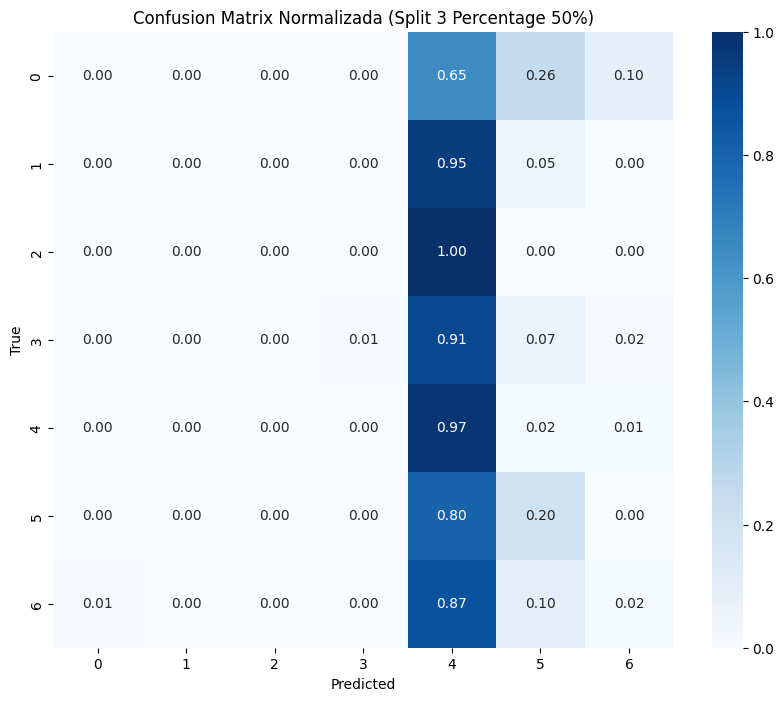

Kappa (Cohen) (Split 3 Percentage 50%): 0.0174
Classification Report (Split 3 Percentage 50%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.00      0.00      0.00        39
           2       0.00      0.00      0.00       362
           3       0.25      0.01      0.01       321
           4       0.17      0.97      0.29       751
           5       0.04      0.20      0.07        95
           6       0.50      0.02      0.03      2858

    accuracy                           0.17      4786
   macro avg       0.14      0.17      0.06      4786
weighted avg       0.34      0.17      0.07      4786

Class Accuracy (Split 3 Percentage 50%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,0,39,0.000000,0.00
class_2,0,362,0.000000,0.00
class_3,2,321,0.006231,0.62
class_4,732,751,0.974700,97.47
class_5,19,95,0.200000,20.00
class_6,46,2858,0.016095,1.61


Overall accuracy: 0.1669    Kappa: 0.0174


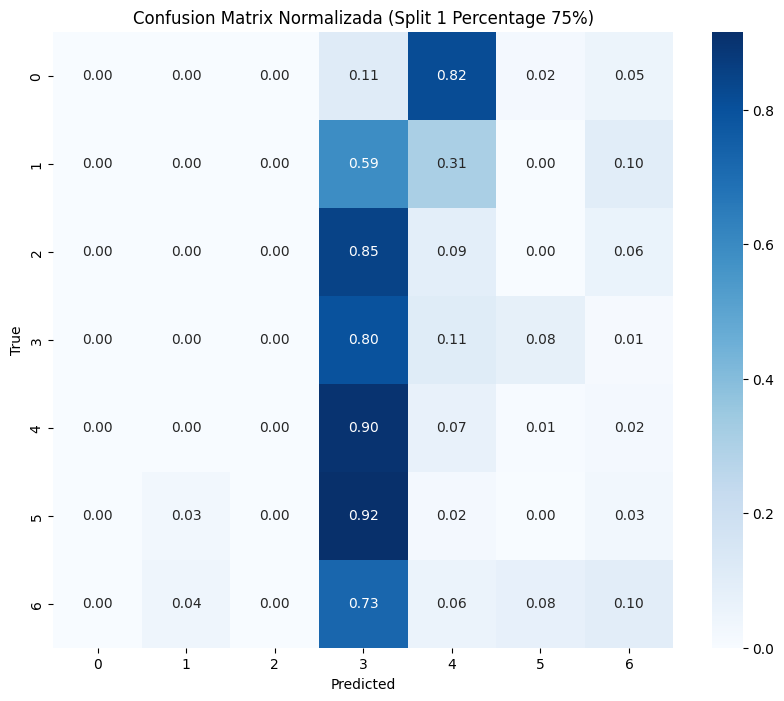

Kappa (Cohen) (Split 1 Percentage 75%): 0.0128
Classification Report (Split 1 Percentage 75%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.00      0.00      0.00        39
           2       0.00      0.00      0.00       362
           3       0.07      0.80      0.14       321
           4       0.09      0.07      0.08       751
           5       0.00      0.00      0.00        95
           6       0.81      0.10      0.18      2858

    accuracy                           0.12      4786
   macro avg       0.14      0.14      0.06      4786
weighted avg       0.51      0.12      0.13      4786

Class Accuracy (Split 1 Percentage 75%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,0,39,0.000000,0.00
class_2,0,362,0.000000,0.00
class_3,256,321,0.797508,79.75
class_4,53,751,0.070573,7.06
class_5,0,95,0.000000,0.00
class_6,286,2858,0.100070,10.01


Overall accuracy: 0.1243    Kappa: 0.0128


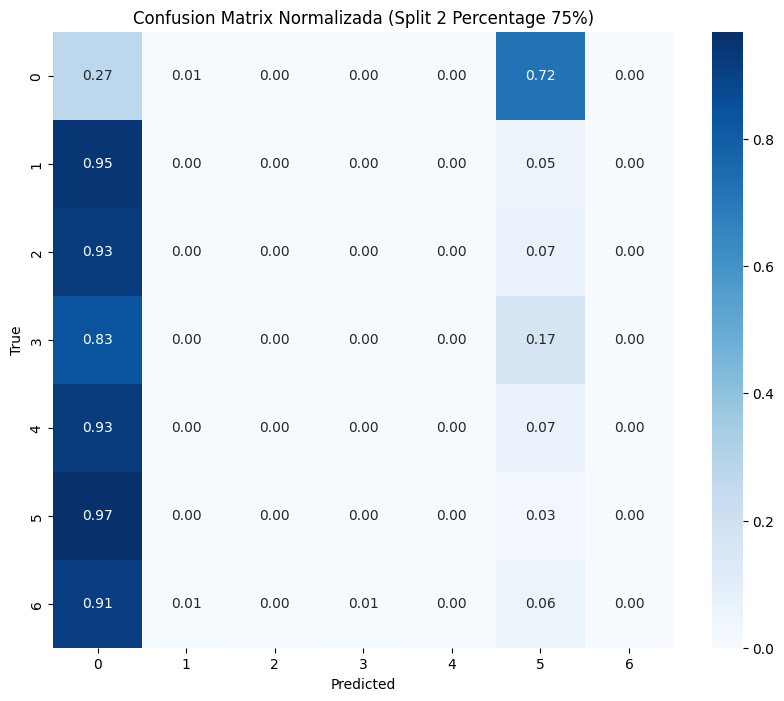

Kappa (Cohen) (Split 2 Percentage 75%): -0.0497
Classification Report (Split 2 Percentage 75%):
              precision    recall  f1-score   support

           0       0.02      0.27      0.04       360
           1       0.00      0.00      0.00        39
           2       0.00      0.00      0.00       362
           3       0.00      0.00      0.00       321
           4       0.00      0.00      0.00       751
           5       0.01      0.03      0.01        95
           6       1.00      0.00      0.01      2858

    accuracy                           0.02      4786
   macro avg       0.15      0.04      0.01      4786
weighted avg       0.60      0.02      0.01      4786

Class Accuracy (Split 2 Percentage 75%):


,correct,total,accuracy,accuracy_pct
class_0,98,360,0.272222,27.22
class_1,0,39,0.000000,0.00
class_2,0,362,0.000000,0.00
class_3,0,321,0.000000,0.00
class_4,0,751,0.000000,0.00
class_5,3,95,0.031579,3.16
class_6,9,2858,0.003149,0.31


Overall accuracy: 0.0230    Kappa: -0.0497


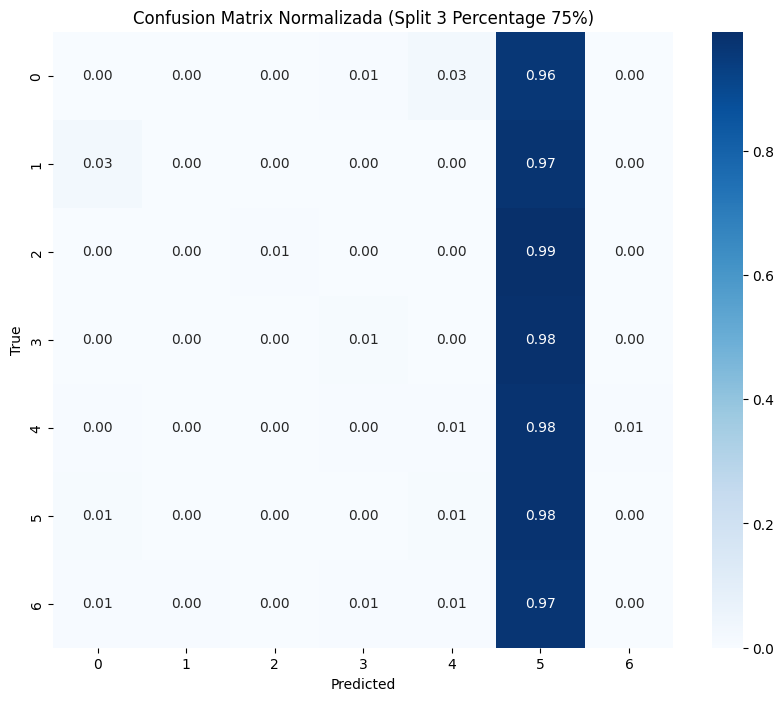

Kappa (Cohen) (Split 3 Percentage 75%): 0.0000
Classification Report (Split 3 Percentage 75%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.00      0.00      0.00        39
           2       0.29      0.01      0.01       362
           3       0.10      0.01      0.02       321
           4       0.13      0.01      0.01       751
           5       0.02      0.98      0.04        95
           6       0.62      0.00      0.01      2858

    accuracy                           0.02      4786
   macro avg       0.16      0.14      0.01      4786
weighted avg       0.42      0.02      0.01      4786

Class Accuracy (Split 3 Percentage 75%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,0,39,0.000000,0.00
class_2,2,362,0.005525,0.55
class_3,3,321,0.009346,0.93
class_4,5,751,0.006658,0.67
class_5,93,95,0.978947,97.89
class_6,8,2858,0.002799,0.28


Overall accuracy: 0.0232    Kappa: 0.0000


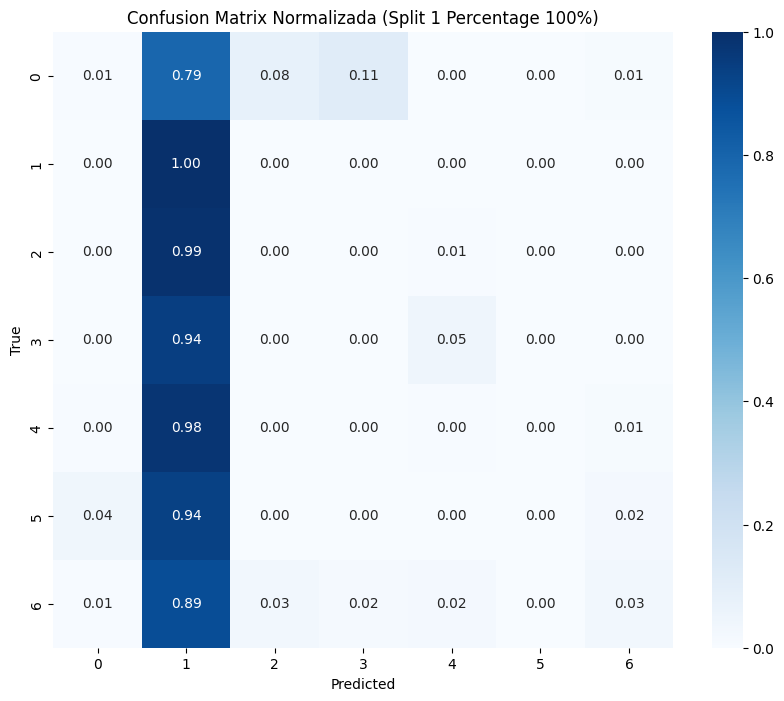

Kappa (Cohen) (Split 1 Percentage 100%): 0.0021
Classification Report (Split 1 Percentage 100%):
              precision    recall  f1-score   support

           0       0.08      0.01      0.01       360
           1       0.01      1.00      0.02        39
           2       0.00      0.00      0.00       362
           3       0.01      0.00      0.00       321
           4       0.04      0.00      0.01       751
           5       0.00      0.00      0.00        95
           6       0.87      0.03      0.06      2858

    accuracy                           0.03      4786
   macro avg       0.14      0.15      0.01      4786
weighted avg       0.53      0.03      0.04      4786

Class Accuracy (Split 1 Percentage 100%):


,correct,total,accuracy,accuracy_pct
class_0,2,360,0.005556,0.56
class_1,39,39,1.000000,100.00
class_2,0,362,0.000000,0.00
class_3,1,321,0.003115,0.31
class_4,3,751,0.003995,0.40
class_5,0,95,0.000000,0.00
class_6,96,2858,0.033590,3.36


Overall accuracy: 0.0295    Kappa: 0.0021


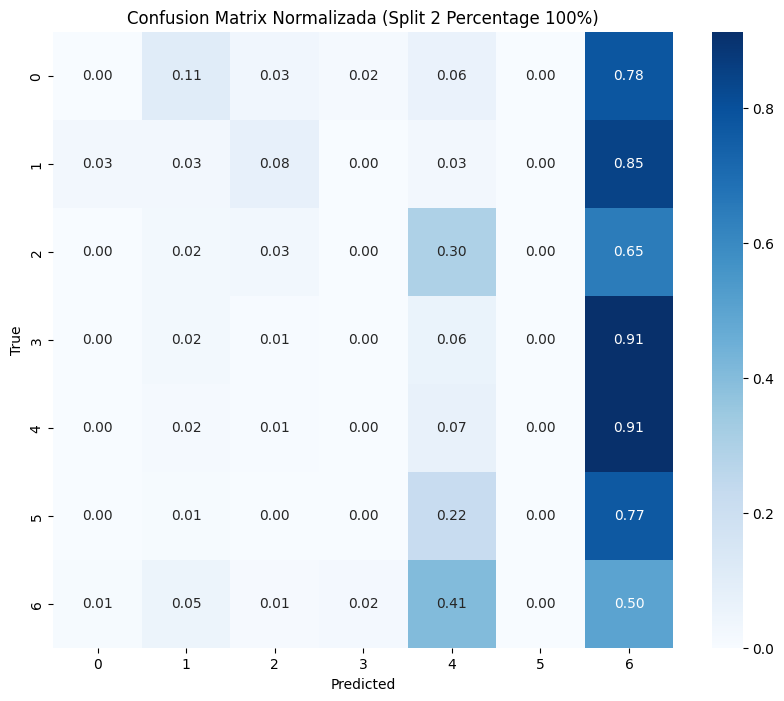

Kappa (Cohen) (Split 2 Percentage 100%): -0.1978
Classification Report (Split 2 Percentage 100%):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.00      0.03      0.01        39
           2       0.16      0.03      0.05       362
           3       0.00      0.00      0.00       321
           4       0.04      0.07      0.05       751
           5       0.00      0.00      0.00        95
           6       0.47      0.50      0.49      2858

    accuracy                           0.31      4786
   macro avg       0.10      0.09      0.08      4786
weighted avg       0.30      0.31      0.30      4786

Class Accuracy (Split 2 Percentage 100%):


,correct,total,accuracy,accuracy_pct
class_0,0,360,0.000000,0.00
class_1,1,39,0.025641,2.56
class_2,11,362,0.030387,3.04
class_3,0,321,0.000000,0.00
class_4,51,751,0.067909,6.79
class_5,0,95,0.000000,0.00
class_6,1436,2858,0.502449,50.24


Overall accuracy: 0.3132    Kappa: -0.1978


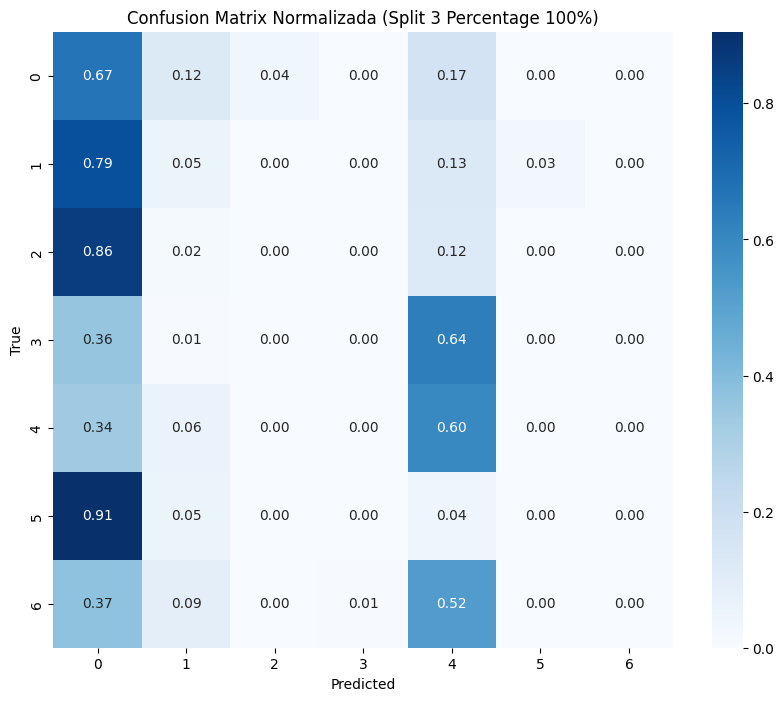

Kappa (Cohen) (Split 3 Percentage 100%): 0.0408
Classification Report (Split 3 Percentage 100%):
              precision    recall  f1-score   support

           0       0.11      0.67      0.20       360
           1       0.01      0.05      0.01        39
           2       0.00      0.00      0.00       362
           3       0.00      0.00      0.00       321
           4       0.20      0.60      0.30       751
           5       0.00      0.00      0.00        95
           6       1.00      0.00      0.00      2858

    accuracy                           0.15      4786
   macro avg       0.19      0.19      0.07      4786
weighted avg       0.64      0.15      0.06      4786

Class Accuracy (Split 3 Percentage 100%):


,correct,total,accuracy,accuracy_pct
class_0,240,360,0.666667,66.67
class_1,2,39,0.051282,5.13
class_2,0,362,0.000000,0.00
class_3,0,321,0.000000,0.00
class_4,450,751,0.599201,59.92
class_5,0,95,0.000000,0.00
class_6,3,2858,0.001050,0.10


Overall accuracy: 0.1452    Kappa: 0.0408


In [13]:
# Avaliaton on test set before training

for perc in CONFIG_CISTO['percentage']:
    for split in CONFIG_CISTO['split']:
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_CISTO['num_classes'])
        model = model.to(CONFIG_CISTO['device'])
        model.eval()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for input, label in tqdm(dataloaders_cisto[split][perc]['test'], desc=f"Testing Split {split} Perc {perc}%", leave=False):
                input, label = input.to(CONFIG_CISTO['device']), label.to(CONFIG_CISTO['device'])

                outputs = model(input)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(label.cpu().numpy())
                
        
        # Confusion Matrix 
        cm = confusion_matrix(all_labels, all_preds, normalize='true')
        # cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
        # evita NaNs quando alguma linha tem soma 0
        # cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=list(range(CONFIG_CISTO['num_classes'])),
                    yticklabels=list(range(CONFIG_CISTO['num_classes'])))
        plt.title(f'Confusion Matrix Normalizada (Split {split} Percentage {perc}%)')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

        # Kappa
        kappa = cohen_kappa_score(all_labels, all_preds)
        print(f'Kappa (Cohen) (Split {split} Percentage {perc}%): {kappa:.4f}')

        # Accuracy per class
        class_correct = np.zeros(CONFIG_CISTO['num_classes'])
        class_total = np.zeros(CONFIG_CISTO['num_classes'])

        # Classification Report
        report = classification_report(all_labels, all_preds, zero_division=0)
        print(f'Classification Report (Split {split} Percentage {perc}%):\n{report}')

        for i in range(len(all_labels)):
            class_total[all_labels[i]] += 1
            class_correct[all_labels[i]] += (all_preds[i] == all_labels[i])

        # evita divisão 0/0: retorna 0 para classes com total 0
        class_accuracy = np.divide(class_correct, class_total, out=np.zeros_like(class_correct, dtype=float), where=class_total != 0)
        
        # Monta DataFrame com as métricas por classe
        df = pd.DataFrame({
            'correct': class_correct.astype(int),
            'total': class_total.astype(int),
            'accuracy': class_accuracy
        }, index=[f'class_{i}' for i in range(CONFIG_CISTO['num_classes'])])

        # adiciona coluna percentual para visualização
        df['accuracy_pct'] = (df['accuracy'] * 100).round(2)

        print(f'Class Accuracy (Split {split} Percentage {perc}%):')
        display(df)

        # mostra resumo geral
        overall_acc = (np.array(all_preds) == np.array(all_labels)).mean() if len(all_labels) > 0 else np.nan
        print(f'Overall accuracy: {overall_acc:.4f}    Kappa: {kappa:.4f}')

In [ ]:
# Training loop
historic_perc = {} 

for perc in CONFIG_CISTOS['percentage']:
    patience = 20
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    best_val_acc = 0.0
    historic_perc[perc] = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in tqdm(range(CONFIG_CISTOS['num_epochs']), desc=f"Percentage {perc}%", leave=False):
        train_loss, train_acc = train(vgg16_model_pretrained, dataloaders_perc[perc]['train'], criterion, optimizer, CONFIG_CISTOS['device'])

        val_loss, val_acc = evaluate(vgg16_model_pretrained, dataloaders_perc[perc]['val'], criterion, CONFIG_CISTOS['device'])

        historic_perc[perc]['train_loss'].append(train_loss)
        historic_perc[perc]['train_acc'].append(train_acc)
        historic_perc[perc]['val_loss'].append(val_loss)
        historic_perc[perc]['val_acc'].append(val_acc)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(vgg16_model_pretrained.state_dict(), f'vgg16_cistos_best_acc_perc_{perc}_split{CONFIG_CISTOS["split"]}.pth')

        scheduler.step()

In [ ]:
from sklearn.metrics import cohen_kappa_score

# Avaliaton on test set
for perc in CONFIG_CISTOS['percentage']:
    # Load the best model
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_CISTOS['num_classes'])
    model.load_state_dict(torch.load(f'vgg16_cistos_best_acc_perc_{perc}_split{CONFIG_CISTOS["split"]}.pth'))
    model = model.to(CONFIG_CISTOS['device'])
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input, label in tqdm(dataloaders_perc[perc]['test'], desc=f"Testing Percentage {perc}%", leave=False):
            input, label = input.to(CONFIG_CISTOS['device']), label.to(CONFIG_CISTOS['device'])

            outputs = model(input)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Confusion Matrix (normalizada por linha - recall por classe)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
    # evita NaNs quando alguma linha tem soma 0
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=list(range(CONFIG_EGG['num_classes'])),
                yticklabels=list(range(CONFIG_EGG['num_classes'])))
    plt.title(f'Confusion Matrix Normalizada (Percentage {perc}%)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Kappa
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'Kappa (Cohen) (Percentage {perc}%): {kappa:.4f}')

    # Classification Report
    report = classification_report(all_labels, all_preds)
    print(f'Classification Report (Percentage {perc}%):\n{report}')

### Larvae

In [ ]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_larvae = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((CONFIG_LARVAE['image_size'], CONFIG_LARVAE['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_LARVAE['split']:
    dataloaders_larvae[split] = {}
    for perc in CONFIG_LARVAE['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_LARVAE['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_LARVAE['batch_size'],
            num_workers=CONFIG_LARVAE['num_workers'],
            transform=transforms_larvae
        )
        data_module.setup()
        dataloaders_larvae[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }
    
# Model
vgg16_model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_model_pretrained.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_LARVAE['num_classes'])
vgg16_model_pretrained = vgg16_model_pretrained.to(CONFIG_LARVAE['device'])

total_params = sum(p.numel() for p in vgg16_model_pretrained.parameters())
trainable_params = sum(p.numel() for p in vgg16_model_pretrained.parameters() if p.requires_grad)

# print(f"Total parameters: {total_params}")
# print(f"Trainable parameters: {trainable_params}")
# print(summary(vgg16_model_pretrained, input_size=(1, 3, 224, 224)))

# Loss , Optimizer and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model_pretrained.parameters(), lr=CONFIG_LARVAE['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
historic_perc = {}

for split in CONFIG_LARVAE['split']:
    historic_perc[split] = {}
    for perc in CONFIG_LARVAE['percentage']:
        patience = 20
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        best_val_acc = 0.0
        historic_perc[split][perc] = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }

        for epoch in tqdm(range(CONFIG_LARVAE['num_epochs']), desc=f"Split {split} - Percentage {perc}%", leave=False):
            train_loss, train_acc = train(vgg16_model_pretrained, dataloaders_larvae[split][perc]['train'], criterion, optimizer, CONFIG_LARVAE['device'])

            val_loss, val_acc = evaluate(vgg16_model_pretrained, dataloaders_larvae[split][perc]['val'], criterion, CONFIG_LARVAE['device'])

            historic_perc[split][perc]['train_loss'].append(train_loss)
            historic_perc[split][perc]['train_acc'].append(train_acc)
            historic_perc[split][perc]['val_loss'].append(val_loss)
            historic_perc[split][perc]['val_acc'].append(val_acc)

            # Early Stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve == patience:
                print(f"Split {split} - Percentage {perc}%: Early stopping triggered at epoch {epoch}")
                break

            # Save the best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(vgg16_model_pretrained.state_dict(), f'vgg16_larvae_best_acc_split{split}_perc_{perc}.pth')

            scheduler.step()

In [ ]:
# Loss and Accuracy plots
for perc in CONFIG_LARVAE['percentage']:
    for split in CONFIG_LARVAE['split']:
        epochs = range(1, len(historic_perc[split][perc]['train_loss']) + 1)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, historic_perc[split][perc]['train_loss'], label='Train Loss')
        plt.plot(epochs, historic_perc[split][perc]['val_loss'], label='Validation Loss')
        plt.title(f'Split {split} - Loss per Epoch (Percentage {perc}%)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, historic_perc[split][perc]['train_acc'], label='Train Accuracy')
        plt.plot(epochs, historic_perc[split][perc]['val_acc'], label='Validation Accuracy')
        plt.title(f'Split {split} - Accuracy per Epoch (Percentage {perc}%)')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

In [ ]:
# Avaliaton on test set
results = {}

for split in CONFIG_LARVAE['split']:
    results[split] = {}
    for perc in CONFIG_LARVAE['percentage']:
        # Load the best model
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_LARVAE['num_classes'])
        model.load_state_dict(torch.load(f'vgg16_larvae_best_acc_split{split}_perc_{perc}.pth'))
        model = model.to(CONFIG_LARVAE['device'])
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for input, label in tqdm(dataloaders_larvae[split][perc]['test'], desc=f"Split {split} - Testing Percentage {perc}%", leave=False):
                input, label = input.to(CONFIG_LARVAE['device']), label.to(CONFIG_LARVAE['device'])

                outputs = model(input)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(label.cpu().numpy())

        # Confusion Matrix (normalizada por linha - recall por classe)
        cm = confusion_matrix(all_labels, all_preds)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
        # evita NaNs quando alguma linha tem soma 0
        cm_norm = np.nan_to_num(cm_norm)

        # plt.figure(figsize=(10, 8))
        # sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
        #             xticklabels=list(range(CONFIG_LARVAE['num_classes'])),
        #             yticklabels=list(range(CONFIG_LARVAE['num_classes'])))
        # plt.title(f'Split {split} - Confusion Matrix Normalizada (Percentage {perc}%)')
        # plt.xlabel('Predicted')
        # plt.ylabel('True')
        # plt.show()

        # Kappa
        kappa = cohen_kappa_score(all_labels, all_preds)
        # print(f'Split {split} - Percentage {perc}%: Kappa (Cohen): {kappa:.4f}')

        # Classification Report
        report = classification_report(all_labels, all_preds)
        # print(f'Split {split} - Percentage {perc}%: Classification Report:\n{report}')
        
        results[split][perc] = {
            'confusion_matrix': cm,
            'confusion_matrix_normalized': cm_norm,
            'kappa': kappa,
            'classification_report': report
        }

In [ ]:
# Visualizar métricas por split, calcular média e desvio padrão; salvar e mostrar uma imagem
# por split contendo subfiguras (uma por porcentagem) com a matriz de confusão normalizada.

splits = sorted(results.keys())
percentages = CONFIG_LARVAE['percentage']

for split in splits:
    rows = []
    acc_list = []
    kappa_list = []
    supports = []
    
    # Figura com subplots: uma coluna por porcentagem
    n = len(percentages)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    
    for i, perc in enumerate(percentages):
        entry = results[split].get(perc)
        if entry is None:
            # garante robustez caso falte alguma entrada
            rows.append({'percentage': perc, 'accuracy': np.nan, 'kappa': np.nan, 'support': 0})
            sns.heatmap(np.zeros((CONFIG_LARVAE['num_classes'], CONFIG_LARVAE['num_classes'])),
                        ax=axes[i], cbar=False, cmap='Blues', annot=False)
            axes[i].set_title(f'Perc {perc}% (sem dados)')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('True')
            continue

        cm = entry['confusion_matrix']
        cm_norm = entry['confusion_matrix_normalized']
        kappa = entry['kappa']
        support = cm.sum()
        accuracy = np.trace(cm) / support if support > 0 else np.nan

        rows.append({'percentage': perc, 'accuracy': accuracy, 'kappa': kappa, 'support': support})
        acc_list.append(accuracy)
        kappa_list.append(kappa)
        supports.append(support)

        # Plot da matriz de confusão normalizada
        ax = axes[i]
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                    xticklabels=list(range(CONFIG_LARVAE['num_classes'])),
                    yticklabels=list(range(CONFIG_LARVAE['num_classes'])))
        ax.set_title(f'Perc {perc}%\nAcc: {accuracy:.3f}  Kappa: {kappa:.3f}\nSupport: {support}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.suptitle(f'Split {split} - Matrizes de Confusão Normalizadas por Porcentagem', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    # salvar figura por split
    fname = f'confusion_matrices_split{split}.png'
    plt.savefig(fname, dpi=200)
    plt.show()

    # DataFrame resumo por porcentagem
    df_metrics = pd.DataFrame(rows).set_index('percentage')
    mean_acc = np.nanmean(acc_list) if len(acc_list) > 0 else np.nan
    std_acc = np.nanstd(acc_list) if len(acc_list) > 0 else np.nan
    mean_kappa = np.nanmean(kappa_list) if len(kappa_list) > 0 else np.nan
    std_kappa = np.nanstd(kappa_list) if len(kappa_list) > 0 else np.nan

    # Mostrar tabela e estatísticas resumidas
    print(f'\n=== Split {split} - Resumo por porcentagem ===')
    display(df_metrics)
    print(f'Média Accuracy: {mean_acc:.4f}    Desvio padrão Accuracy: {std_acc:.4f}')
    print(f'Média Kappa:    {mean_kappa:.4f}    Desvio padrão Kappa:    {std_kappa:.4f}\n')

# Opcional: resumo agregado entre splits (média e desvio por porcentagem)
agg_rows = []
for perc in percentages:
    accs = []
    kappas = []
    for split in splits:
        e = results[split].get(perc)
        if e is None:
            continue
        cm = e['confusion_matrix']
        supp = cm.sum()
        acc = np.trace(cm) / supp if supp > 0 else np.nan
        accs.append(acc)
        kappas.append(e['kappa'])
    agg_rows.append({
        'percentage': perc,
        'acc_mean_across_splits': np.nanmean(accs) if accs else np.nan,
        'acc_std_across_splits': np.nanstd(accs) if accs else np.nan,
        'kappa_mean_across_splits': np.nanmean(kappas) if kappas else np.nan,
        'kappa_std_across_splits': np.nanstd(kappas) if kappas else np.nan
    })

df_agg = pd.DataFrame(agg_rows).set_index('percentage')
print('=== Resumo agregado entre splits (por porcentagem) ===')
display(df_agg)